Interactive conversion of GHL from COGs to IceChunk as part of distribution via Earthmover. Following: https://icechunk.io/en/stable/guides/ingestion/glad-ingest/ for the general idea.

Ticket: https://github.com/Space-Intelligence/issues/issues/1381

In [1]:
# ---- Imports ----
import datetime
import itertools
import pathlib

import coiled
import dask
import dask.array
import icechunk as ic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
import yaml
from azure.identity import DefaultAzureCredential
from azure.storage.blob import BlobServiceClient, BlobSasPermissions, generate_blob_sas
from distributed import wait
from icechunk.session import ForkSession
from icechunk.xarray import to_icechunk
from odc.geo.geobox import GeoBox
from rasterio.env import Env

rxr.set_options(export_grid_mapping=False)

DASK_CHUNK_SIZE = (1, 5000, 5000)  # 40_000px tiles / 5000 = 8 chunks per tile edge

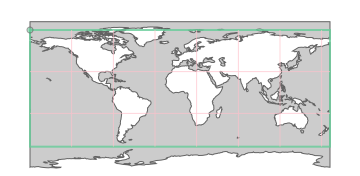

In [2]:
# ---- Load config and set up Azure storage client + SAS URL helper ----
ASSETS_PATH = pathlib.Path("assets.yaml")

with ASSETS_PATH.open() as f:
    assets_cfg = yaml.safe_load(f)

YEAR = int(list(assets_cfg["dates"].keys())[0])   # 2024
TILES = assets_cfg["tiles"]
PREFIX = assets_cfg["storage"]["prefix"]          # {"forest_carbon": ..., ...}

STORAGE_ACCOUNT = assets_cfg["storage"]["account"]
CONTAINER = assets_cfg["storage"]["container"]

credential = DefaultAzureCredential()

_blob_service_client = BlobServiceClient(
    account_url=f"https://{STORAGE_ACCOUNT}.blob.core.windows.net",
    credential=credential,
)

def tile_url(asset_type: str, tile: str) -> str:
    """Return a signed read URL for a GHL COG tile."""
    blob_name = f"{PREFIX[asset_type]}/{tile}.tif"

    expiry = datetime.datetime.now(datetime.timezone.utc) + datetime.timedelta(hours=6)
    start = datetime.datetime.now(datetime.timezone.utc) - datetime.timedelta(minutes=5)

    user_delegation_key = _blob_service_client.get_user_delegation_key(
        key_start_time=start,
        key_expiry_time=expiry,
    )
    sas_token = generate_blob_sas(
        account_name=STORAGE_ACCOUNT,
        container_name=CONTAINER,
        blob_name=blob_name,
        user_delegation_key=user_delegation_key,
        permission=BlobSasPermissions(read=True),
        expiry=expiry,
        start=start,
    )
    return (
        f"https://{STORAGE_ACCOUNT}.blob.core.windows.net"
        f"/{CONTAINER}/{blob_name}?{sas_token}"
    )

# 10 deg tile at 40k px => 0.00025 deg/px
RES = 0.00025

# Full GHL coverage: lon -180..180, lat -60..80
GLOBAL_BBOX = (-180.0, -60.0, 180.0, 80.0)

global_gbox = GeoBox.from_bbox(
    GLOBAL_BBOX,
    crs="EPSG:4326",
    resolution=RES,
    anchor="edge",
)
global_gbox

In [3]:
# ---- Define read_tile: reads one COG tile for one year as a lazy xarray Dataset ----
def read_tile(
    tile: str,
    year: int = YEAR,
    *,
    chunks: dict | None = {},
) -> xr.Dataset:
    """
    Read one GHL tile (e.g. '70N_180W') for one year, returning a Dataset with:
    - deforestation
    - land_cover
    - forest_carbon
    """
    assets = {
        "deforestation": "deforestation",
        "land_cover": "land_cover",
        "forest_carbon": "forest_carbon",
    }

    vars_ds: list[xr.Dataset] = []
    with Env(GDAL_CACHEMAX=0, VSI_CACHE=False, VSI_CACHE_SIZE=0):
        for asset_key, var_name in assets.items():
            ds_asset = (
                xr.open_dataset(
                    tile_url(asset_key, tile),
                    engine="rasterio",
                    chunks=chunks,
                    mask_and_scale=False,
                    lock=False,
                )
                .rename({"band_data": var_name})
                .squeeze("band", drop=True)
                .expand_dims(year=[year])
            )
            vars_ds.append(ds_asset)

    return xr.merge(vars_ds, compat="override", join="exact")


ds = read_tile(tile="70N_180W", year=YEAR)
ds

<xarray.Dataset> Size: 6GB
Dimensions:        (year: 1, x: 40000, y: 40000)
Coordinates:
  * year           (year) int64 8B 2024
  * x              (x) float64 320kB -180.0 -180.0 -180.0 ... -170.0 -170.0
  * y              (y) float64 320kB 70.0 70.0 70.0 70.0 ... 60.0 60.0 60.0 60.0
    spatial_ref    int64 8B ...
Data variables:
    deforestation  (year, y, x) uint8 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    land_cover     (year, y, x) uint8 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    forest_carbon  (year, y, x) uint16 3GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

In [12]:
# ---- Build the global template dataset from collection.yaml metadata ----
# Creates a zero-filled Dataset with the correct shape, dtypes, and attributes
# for the full global grid. Used to initialise the IceChunk store metadata.
collection_cfg = yaml.safe_load(pathlib.Path("collection.yaml").read_text())

asset_order = ["deforestation", "land_cover", "forest_carbon"]
dtype_map = {"uint8": np.uint8, "uint16": np.uint16}

chunks = (1, DASK_CHUNK_SIZE[1], DASK_CHUNK_SIZE[2])

# Read one real tile to carry a valid spatial_ref coordinate
sample = read_tile(tile="70N_180W", year=YEAR)


def _classification_value_map(meta: dict) -> dict | None:
    classification = meta.get("classification")
    if not isinstance(classification, list):
        return None

    value_map = {}
    for item in classification:
        if not isinstance(item, dict):
            continue
        value = item.get("value")
        if value is None:
            continue
        label = item.get("name")
        if label is not None:
            value_map[value] = label

    return value_map or None


def _classification_group_map(meta: dict) -> dict | None:
    groups = (meta.get("si") or {}).get("groups")
    if not isinstance(groups, list):
        return None

    group_map = {}
    for group in groups:
        if not isinstance(group, dict):
            continue
        group_label = group.get("title") or group.get("name")
        values = group.get("values")
        if group_label is not None and isinstance(values, list) and values:
            group_map[group_label] = values

    return group_map or None


def _asset_attrs(asset_name: str) -> dict:
    meta = collection_cfg["item_assets"][asset_name]
    attrs = {
        "long_name": meta.get("title"),
        "description": meta.get("description"),
        "dtype": meta.get("data_type"),
        "unit": meta.get("unit"),
        "nodata": meta.get("nodata"),
        "classification_values": _classification_value_map(meta),
        "classification_groups": _classification_group_map(meta),
    }
    return {k: v for k, v in attrs.items() if v is not None}


ny, nx = global_gbox.shape
years = np.array([YEAR], dtype=np.int16)

# Pixel-center coordinates derived from the global geobox affine
# anchor="edge" means affine origin is at the outer edge of pixel 0,
# so pixel i centre = origin + resolution * (i + 0.5)
a = global_gbox.affine
x_coords = a.c + a.a * (np.arange(nx) + 0.5)
y_coords = a.f + a.e * (np.arange(ny) + 0.5)

template = xr.Dataset(
    data_vars={
        asset: (
            ("year", "y", "x"),
            dask.array.zeros(
                (len(years), ny, nx),
                chunks=chunks,
                dtype=dtype_map[collection_cfg["item_assets"][asset]["data_type"]],
            ),
            _asset_attrs(asset),
        )
        for asset in asset_order
    },
    coords={
        "year": ("year", years),
        "y": ("y", y_coords),
        "x": ("x", x_coords),
        "spatial_ref": sample.spatial_ref,
    },
    attrs={
        "title": collection_cfg["title"],
        "description": collection_cfg["description"],
        "license": collection_cfg["license"],
        "crs": collection_cfg["crs"],
    },
)

template.spatial_ref.attrs["GeoTransform"] = (
    f"{a.c:.1f} {a.a:.5f} {a.b:.1f} {a.f:.1f} {a.d:.1f} {a.e:.5f}"
)

In [13]:
# ---- Inspect the template structure before writing ----
template

<xarray.Dataset> Size: 3TB
Dimensions:        (year: 1, y: 560000, x: 1440000)
Coordinates:
  * year           (year) int16 2B 2024
  * y              (y) float64 4MB 80.0 80.0 80.0 80.0 ... -60.0 -60.0 -60.0
  * x              (x) float64 12MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref    int64 8B ...
Data variables:
    deforestation  (year, y, x) uint8 806GB dask.array<chunksize=(1, 5000, 5000), meta=np.ndarray>
    land_cover     (year, y, x) uint8 806GB dask.array<chunksize=(1, 5000, 5000), meta=np.ndarray>
    forest_carbon  (year, y, x) uint16 2TB dask.array<chunksize=(1, 5000, 5000), meta=np.ndarray>
Attributes:
    title:        Global Harmonised Layers (GHL)
    description:  Harmonised landcover, deforestation by year, and abovegroun...
    license:      CC-BY-NC-4.0
    crs:          EPSG:4326

In [14]:
# ---- Initialise IceChunk store: create repo and write array metadata only (no data) ----
ICECHUNK_ACCOUNT = "spaceintelliexternal"
ICECHUNK_CONTAINER = "earthmover"
ICECHUNK_PREFIX = "ghl/2025/v1"

bearer_token = credential.get_token("https://storage.azure.com/.default").token

storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT,
    container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX,
    bearer_token=bearer_token,
)

# Create once, open if it already exists
try:
    repo = ic.Repository.create(storage)
except Exception:
    repo = ic.Repository.open(storage)

ZARR_CHUNK_SIZE = DASK_CHUNK_SIZE  # must match Dask chunks to avoid write conflicts

# Per-variable encoding: chunk layout + nodata fill value from collection metadata
encoding = {
    asset: {
        "chunks": ZARR_CHUNK_SIZE,
        "fill_value": collection_cfg["item_assets"][asset]["nodata"],
    }
    for asset in asset_order
}

session = repo.writable_session("main")
template.to_zarr(
    session.store,
    compute=False,   # write only metadata, no data yet
    mode="w",
    encoding=encoding,
    consolidated=False,
)
session.commit("initialize array metadata")


'WQV1J907RDZJJHFPFWV0'

In [7]:
# ---- Launch Coiled cluster for distributed tile writes ----
# Coiled prefers uv.lock when present; disable so workers sync the full installed env.
dask.config.set({"coiled.package_sync.use_lockfile.uv": False})

cluster = coiled.Cluster(
    workspace="si-dev",
    n_workers=[2, 5],  # adaptive min/max
    worker_vm_types=["Standard_E4ds_v6"],
    scheduler_vm_types=["Standard_E2ds_v6"],
    spot_policy="spot",
)

client = cluster.get_client()
print(client)
print("Dashboard:", client.dashboard_link)

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                ╷                                             │
│   Package                      │ Note                                        │
│ ╶──────────────────────────────┼───────────────────────────────────────────╴ │
│   coiled_local_jupyter_debug   │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/jupyter_debug          │
│   coiled_local_pydev           │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/pydev                  │
│   coiled_local_si_integrations │ Source wheel built from                     │
│                                │ ~/PycharmProjects/si-integrations           │
│   python                       │ https://conda.anaconda.org/conda-forge/,c   │
│                                │ onda-forge                                  │
│                                ╵                                             │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-05-25 16:35:24,199 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=2 maximum=5


<Client: 'tls://10.8.0.10:8786' processes=2 threads=8, memory=61.01 GiB>
Dashboard: https://cluster-lgqsv.dask.host/FDJeN5CBbi7dmned/status


In [19]:
# ---- Write tiles to IceChunk in parallel on the Coiled cluster ----
# Each tile is dispatched as a dask.delayed task using a forked session.
# Forked sessions are merged back into the main session before committing.

test_tiles = ["60N_010W", "60N_000E"]

year_to_index = {int(y): i for i, y in enumerate(template.year.values)}

def region_for_tile(tile_ds: xr.Dataset, *, year: int) -> dict[str, slice]:
    """
    Calculate zarr region slices from tile bounds using rio.bounds().
    """
    minx, miny, maxx, maxy = tile_ds.rio.bounds()
    a = global_gbox.affine

    col0 = int(round((minx - a.c) / a.a))
    col1 = int(round((maxx - a.c) / a.a))
    row_top = int(round((maxy - a.f) / a.e))
    row_bottom = int(round((miny - a.f) / a.e))

    y0, y1 = sorted((row_top, row_bottom))
    x0, x1 = sorted((col0, col1))
    yi = year_to_index[int(year)]

    return {"year": slice(yi, yi + 1), "y": slice(y0, y1), "x": slice(x0, x1)}


def update_tile(*, session: ForkSession, tile: str, year: int) -> ForkSession:
    """
    Read a single tile and write it to the appropriate region of the Icechunk store.
    Returns the ForkSession for later merging.
    """
    tile_ds = read_tile(tile=tile, year=year)
    region = region_for_tile(tile_ds, year=year)

    # Apply nodata masking: use land_cover == 0 as the unmapped-extent mask
    lc = tile_ds["land_cover"]
    no_data_mask = lc == 0

    tile_ds = tile_ds.assign(
        forest_carbon=tile_ds["forest_carbon"].where(~no_data_mask, other=65535),
        deforestation=tile_ds["deforestation"].where(~no_data_mask, other=255),
        land_cover=lc.where(~no_data_mask, other=255),
    )

    # Rechunk to match Zarr chunk layout to avoid alignment errors
    tile_ds_chunked = tile_ds.chunk({"year": 1, "y": DASK_CHUNK_SIZE[1], "x": DASK_CHUNK_SIZE[2]})

    to_icechunk(
        tile_ds_chunked.drop_vars("spatial_ref", errors="ignore"),
        session,
        region=region,
    )
    return session


# Re-open repo with fresh bearer token before forking sessions
bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT,
    container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX,
    bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
session = repo.writable_session("main")

write_tasks = []
for tile in test_tiles:
    forked = session.fork()
    task = dask.delayed(update_tile)(session=forked, tile=tile, year=YEAR)
    write_tasks.append(task)

distributed_sessions = dask.compute(*write_tasks, scheduler=client)

session.merge(*distributed_sessions)
snap = session.commit(f"write tiles: {', '.join(test_tiles)}")
print("Committed snapshot:", snap)

Committed snapshot: GBEWJJCNG9TDG2T0K8HG


In [16]:
# ---- Inspect the IceChunk store: print snapshot history and open the dataset ----
repo = ic.Repository.open(storage)

print("Snapshot ancestry:")
for snap in repo.ancestry(branch="main"):
    print(" ", snap)

ds = xr.open_dataset(
    repo.readonly_session("main").store,
    engine="zarr",
    consolidated=False,
)
ds

Snapshot ancestry:
  <icechunk.snapshots.SnapshotInfo>
id: ZFHWJ8X768A8M2DSH2D0
parent_id: WQV1J907RDZJJHFPFWV0
written_at: datetime.datetime(2026,5,25,15,48,4,266460, tzinfo=datetime.timezone.utc)
message: write tiles: 70N_180W, 70N_170W
metadata: PySnapshotProperties({})

  <icechunk.snapshots.SnapshotInfo>
id: WQV1J907RDZJJHFPFWV0
parent_id: XJSN4RHR326MP4BXPTK0
written_at: datetime.datetime(2026,5,25,15,45,21,843758, tzinfo=datetime.timezone.utc)
message: initialize array metadata
metadata: PySnapshotProperties({})

  <icechunk.snapshots.SnapshotInfo>
id: XJSN4RHR326MP4BXPTK0
parent_id: 0K3J5XH2PCG36NWWS42G
written_at: datetime.datetime(2026,5,25,15,38,2,874112, tzinfo=datetime.timezone.utc)
message: write tiles: 70N_180W, 70N_170W
metadata: PySnapshotProperties({})

  <icechunk.snapshots.SnapshotInfo>
id: 0K3J5XH2PCG36NWWS42G
parent_id: 1CECHNKREP0F1RSTCMT0
written_at: datetime.datetime(2026,5,25,15,33,11,668307, tzinfo=datetime.timezone.utc)
message: initialize array metadata
met

<xarray.Dataset> Size: 3TB
Dimensions:        (year: 1, y: 560000, x: 1440000)
Coordinates:
  * year           (year) int16 2B 2024
  * y              (y) float64 4MB 80.0 80.0 80.0 80.0 ... -60.0 -60.0 -60.0
  * x              (x) float64 12MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref    int64 8B ...
Data variables:
    forest_carbon  (year, y, x) uint16 2TB ...
    deforestation  (year, y, x) uint8 806GB ...
    land_cover     (year, y, x) uint8 806GB ...
Attributes:
    title:        Global Harmonised Layers (GHL)
    description:  Harmonised landcover, deforestation by year, and abovegroun...
    license:      CC-BY-NC-4.0
    crs:          EPSG:4326

Region shape: FrozenMappingWarningOnValuesAccess({'y': 48000, 'x': 88000})


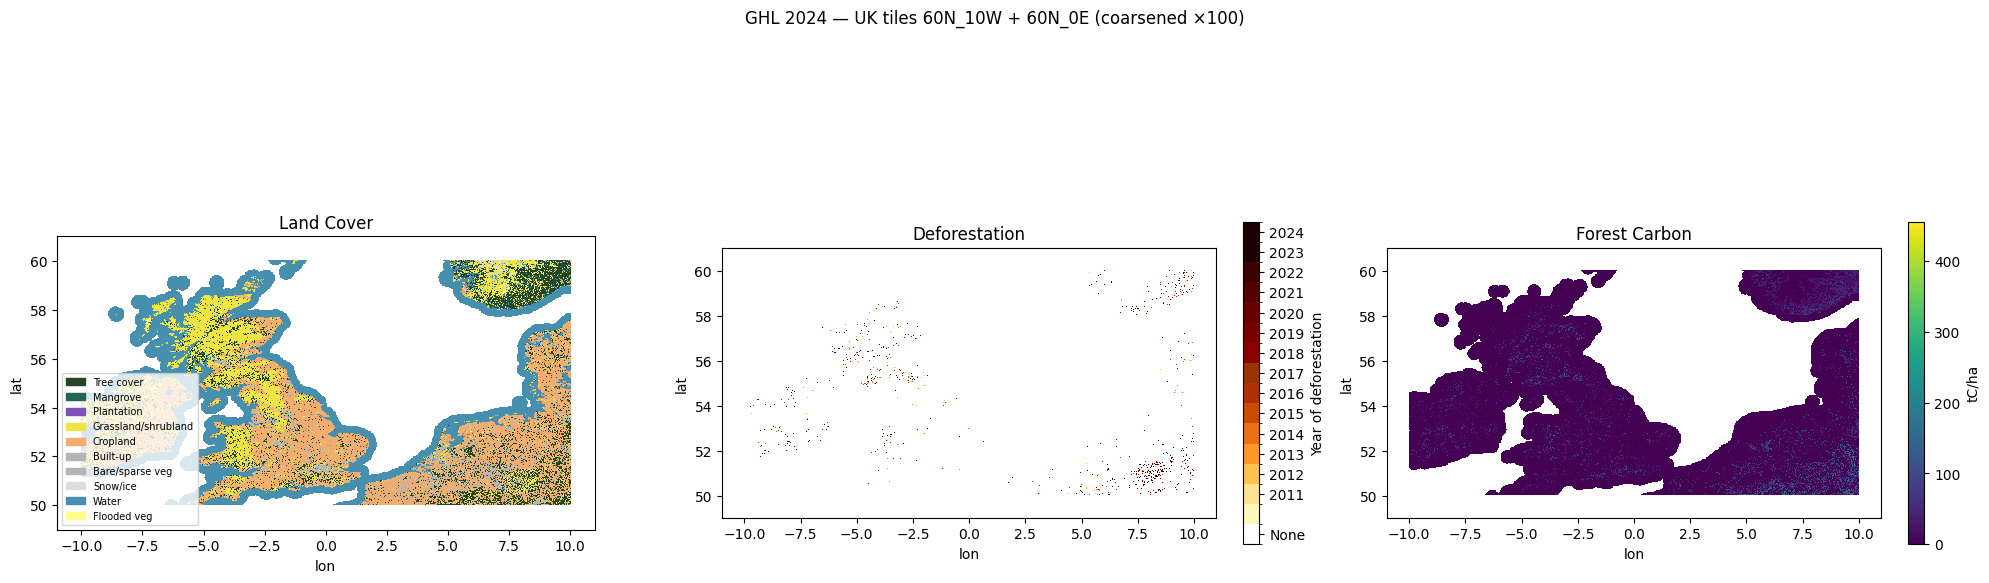

In [23]:
# ---- Visualise written tile regions: coarsen and plot to verify correctness ----
# Opens the store lazily (dask-backed), computes the coarsening on the Coiled cluster,
# then pulls the small result locally for plotting.
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

repo = ic.Repository.open(storage)
ds = xr.open_dataset(
    repo.readonly_session("main").store,
    engine="zarr",
    consolidated=False,
    chunks={},  # lazy dask arrays — computation runs on the cluster
)

# UK tiles: 60N_10W and 60N_0E → lon -10..10, lat 50..60
BUFFER = 1.0
lon_min = max(-10.0 - BUFFER, float(ds.x.min()))
lon_max = min( 10.0 + BUFFER, float(ds.x.max()))
lat_min = max( 50.0 - BUFFER, float(ds.y.min()))
lat_max = min( 60.0 + BUFFER, float(ds.y.max()))

region_ds = ds.sel(x=slice(lon_min, lon_max), y=slice(lat_max, lat_min), year=YEAR)
print(f"Region shape: {region_ds.dims}")

COARSEN = 100
# "nearest" equivalent: subsample every Nth pixel rather than aggregating
coarse = region_ds.isel(x=slice(None, None, COARSEN), y=slice(None, None, COARSEN)).compute(scheduler=client)

# ── Styling ────────────────────────────────────────────────────────────────────

# land_cover: discrete colormap, values 1-10, nodata (0/255) → masked
LC_COLORS  = ['#234626','#236656','#7E52B6','#F0E442','#F8AC6B',
               '#B4B4B4','#B4B4B4','#DDDDDD','#468FAF','#FFFF8C']
LC_LABELS  = ['Tree cover','Mangrove','Plantation','Grassland/shrubland',
               'Cropland','Built-up','Bare/sparse veg','Snow/ice','Water','Flooded veg']
lc_cmap = ListedColormap(LC_COLORS)
lc_norm = BoundaryNorm(np.arange(0.5, 11.5, 1), ncolors=10)

# deforestation: 0 = no loss (white), 11-24 = yellow→dark red, nodata (255) → masked
DEFOR_COLORS = ['#FFFFFF',
                '#FFF7BC','#FEE391','#FEC44F','#FE9929','#EC7014','#CC4C02',
                '#B03007','#993404','#8B0000','#7A0000','#680000','#520000',
                '#3D0000','#1A0000']
defor_cmap  = ListedColormap(DEFOR_COLORS)
defor_bounds = [-0.5, 0.5] + [v + 0.5 for v in range(10, 25)]
defor_norm  = BoundaryNorm(defor_bounds, ncolors=len(defor_bounds) - 1)

# forest_carbon: viridis 0-455 tC/ha, nodata (65535) → masked

# ── Plot ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
extent = [lon_min, lon_max, lat_min, lat_max]

# --- land_cover ---
lc_data = coarse["land_cover"].squeeze().values.astype(float)
lc_data[lc_data == 255] = np.nan
axes[0].imshow(lc_data, origin="upper", extent=extent,
               cmap=lc_cmap, norm=lc_norm, interpolation="none")
axes[0].set_title("Land Cover")
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(LC_COLORS, LC_LABELS)]
axes[0].legend(handles=patches, fontsize=7, loc="lower left",
               framealpha=0.8, ncol=1)

# --- deforestation ---
# remap: 0 stays 0, values 1-10 don't exist, 11-24 stay as-is, 255 → nan
defor_data = coarse["deforestation"].squeeze().values.astype(float)
defor_data[defor_data == 255] = np.nan
im_d = axes[1].imshow(defor_data, origin="upper", extent=extent,
                      cmap=defor_cmap, norm=defor_norm, interpolation="none")
cbar_d = plt.colorbar(im_d, ax=axes[1], fraction=0.03)
cbar_d.set_ticks([0] + list(range(11, 25)))
cbar_d.set_ticklabels(["None"] + [str(2000 + v) for v in range(11, 25)])
cbar_d.set_label("Year of deforestation")
axes[1].set_title("Deforestation")

# --- forest_carbon ---
fc_data = coarse["forest_carbon"].squeeze().values.astype(float)
fc_data[fc_data == 65535] = np.nan
im_fc = axes[2].imshow(fc_data, origin="upper", extent=extent,
                       cmap="viridis", vmin=0, vmax=455, interpolation="none")
cbar_fc = plt.colorbar(im_fc, ax=axes[2], fraction=0.03)
cbar_fc.set_label("tC/ha")
axes[2].set_title("Forest Carbon")

for ax in axes:
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

plt.suptitle(f"GHL {YEAR} — UK tiles 60N_10W + 60N_0E (coarsened ×{COARSEN})", y=1.01)
plt.tight_layout()
plt.show()